# NO tests
The following notebook contains tests to verify our implementation of spontaneous Raman scattering of the NO molecule.

In [1]:
import wedme
import numpy as np
import matplotlib.pyplot as plt 
from ramlab.molecules import NO, NO_Hitran
wedme.apply.dev()

In [2]:
transitions = NO_Hitran.get_all_transitions()

Loading csv file: 308000rows [00:01, 193964.82rows/s]


Rejected 1 lines with a length not equal to 160.


Median error: 0.23 cm^-1
Standard deviation of the error: 0.80 cm^-1
Maximum absolute error: 3.65 cm^-1


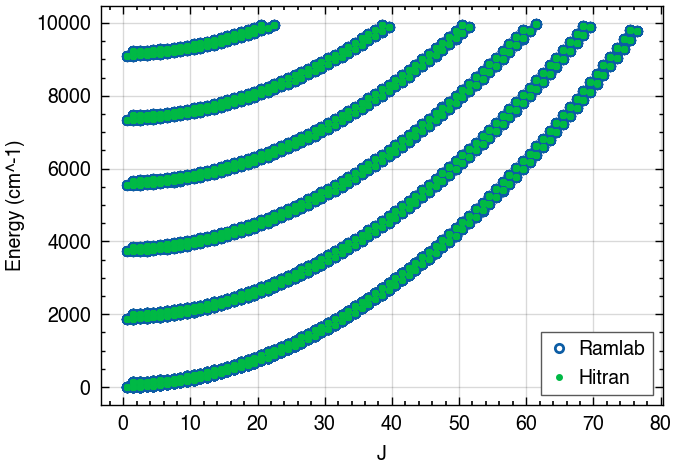

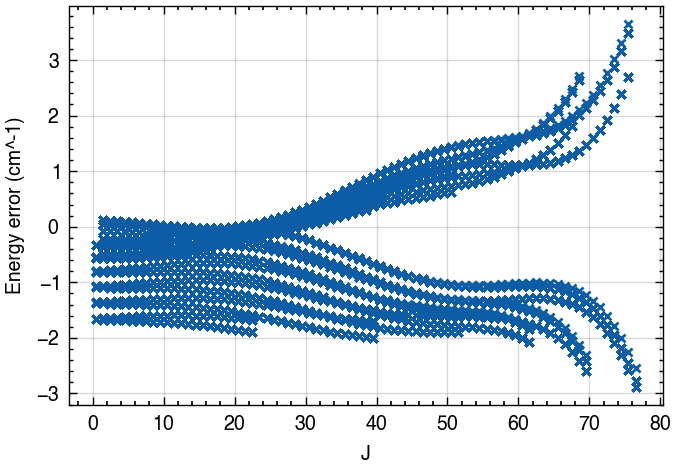

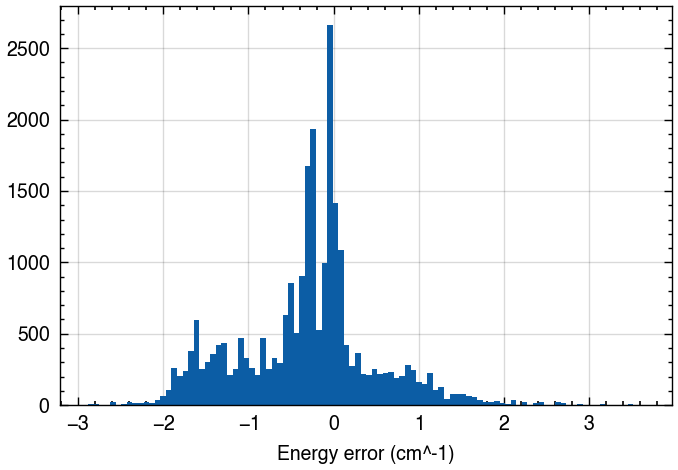

In [11]:
idx = transitions.initial_E < 10e3  # Filter out high energy states. We have no desire to fit these accurately.
state_final = transitions.state_final[idx]
state_initial = transitions.state_initial[idx]

E_hitran = state_initial.E
E_ramlab = NO.E(state_initial)

print(f"Median error: {np.median(E_hitran - E_ramlab):.2f} cm^-1")
print(f"Standard deviation of the error: {np.std(E_hitran - E_ramlab):.2f} cm^-1")
print(f"Maximum absolute error: {np.max(np.abs(E_hitran - E_ramlab)):.2f} cm^-1")

plt.figure()
plt.plot(state_initial.J, E_ramlab, 'o', markerfacecolor='none')
plt.plot(state_initial.J, E_hitran, '.')
plt.xlabel("J")
plt.ylabel("Energy (cm^-1)")
plt.legend(["Ramlab", "Hitran"])

plt.figure()
plt.plot(state_initial.J, E_ramlab - E_hitran, 'x')
plt.xlabel("J")
plt.ylabel("Energy error (cm^-1)")
plt.show()

plt.figure()
plt.hist(E_ramlab - E_hitran, bins=100)
plt.xlabel("Energy error (cm^-1)")
plt.show()